<a href="https://colab.research.google.com/github/sathvikteja/MachineLearningAlgorithms/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classification

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

#Loading and preprocessing
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Train/Val/Test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Converting to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

Defining Models

In [ ]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, activation='relu'):
        super().__init__()
        layers = []
        prev_dim = input_dim
        act_fn = nn.ReLU if activation=='relu' else nn.Sigmoid
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(act_fn())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

Training Function

In [ ]:
def train_model(model, X_train, y_train, X_val, y_val, optimizer_type='SGD',
                lr=0.01, weight_decay=0.0, batch_size=None, epochs=200):

    criterion = nn.CrossEntropyLoss()

    if optimizer_type=='SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type=='Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    if batch_size is None:
        batch_size = len(X_train)  # full-batch
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

    # Validation accuracy
    model.eval()
    with torch.no_grad():
        val_out = model(X_val)
        val_preds = torch.argmax(val_out, axis=1)
        val_acc = (val_preds == y_val).float().mean().item()
    return val_acc, model

Experimenting different combinations

In [ ]:
results = []

hidden_configs = [[], [10], [10,10]]  # no hidden, 1 hidden, 2 hidden
activations = ['relu', 'sigmoid']
optimizers = ['SGD', 'Adam']
batch_sizes = [None, 16]  # full-batch (None) or mini-batch 16
weight_decays = [0.0, 0.01]

input_dim = X_train.shape[1]
output_dim = len(np.unique(y))

for hidden in hidden_configs:
    for act in activations:
        for opt in optimizers:
            for bs in batch_sizes:
                for wd in weight_decays:
                    model = FeedForwardNN(input_dim, hidden, output_dim, activation=act)
                    val_acc, trained_model = train_model(model, X_train_tensor, y_train_tensor,
                                                         X_val_tensor, y_val_tensor,
                                                         optimizer_type=opt, weight_decay=wd,
                                                         batch_size=bs)
                    # Test accuracy
                    trained_model.eval()
                    with torch.no_grad():
                        test_out = trained_model(X_test_tensor)
                        test_preds = torch.argmax(test_out, axis=1)
                        test_acc = (test_preds == y_test_tensor).float().mean().item()

                    results.append({
                        'Hidden Layers': len(hidden),
                        'Units': hidden if hidden else '-',
                        'Activation': act,
                        'Optimizer': opt,
                        'Batch Size': 'Full' if bs is None else bs,
                        'L2': wd,
                        'Val Acc': round(val_acc,4),
                        'Test Acc': round(test_acc,4)
                    })


Reporting the results

In [ ]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='Val Acc', ascending=False)
print(df_results.head(10).to_string(index=False))  # top 10 models

 Hidden Layers    Units Activation Optimizer Batch Size   L2  Val Acc  Test Acc
             0        -       relu       SGD         16 0.01   0.9091    0.8261
             0        -       relu      Adam         16 0.00   0.9091    0.9565
             0        -    sigmoid      Adam         16 0.00   0.9091    0.9565
             0        -    sigmoid       SGD         16 0.01   0.9091    0.8261
             2 [10, 10]       relu       SGD         16 0.01   0.9091    0.9130
             2 [10, 10]       relu      Adam         16 0.01   0.9091    0.9130
             1     [10]       relu      Adam         16 0.01   0.9091    1.0000
             1     [10]       relu      Adam         16 0.00   0.9091    0.9565
             2 [10, 10]       relu      Adam         16 0.00   0.9091    0.9130
             2 [10, 10]    sigmoid      Adam         16 0.00   0.9091    0.9565


Reporting Results in Tabular format

In [ ]:
from tabulate import tabulate

# Pretty print without indices
print(tabulate(df_results, headers='keys', tablefmt='psql', showindex=False))

+-----------------+----------+--------------+-------------+--------------+------+-----------+------------+
|   Hidden Layers | Units    | Activation   | Optimizer   | Batch Size   |   L2 |   Val Acc |   Test Acc |
|-----------------+----------+--------------+-------------+--------------+------+-----------+------------|
|               0 | -        | relu         | SGD         | 16           | 0.01 |    0.9091 |     0.8261 |
|               0 | -        | relu         | Adam        | 16           | 0    |    0.9091 |     0.9565 |
|               0 | -        | sigmoid      | Adam        | 16           | 0    |    0.9091 |     0.9565 |
|               0 | -        | sigmoid      | SGD         | 16           | 0.01 |    0.9091 |     0.8261 |
|               2 | [10, 10] | relu         | SGD         | 16           | 0.01 |    0.9091 |     0.913  |
|               2 | [10, 10] | relu         | Adam        | 16           | 0.01 |    0.9091 |     0.913  |
|               1 | [10]     | relu  

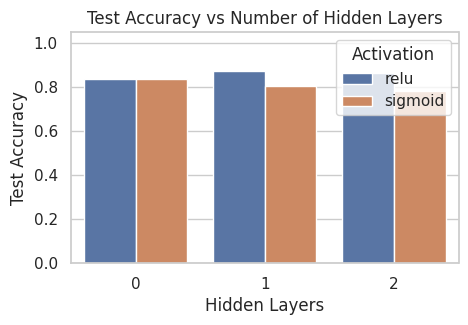

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1. Test Accuracy vs Hidden Layers
plt.figure(figsize=(5,3))
sns.barplot(data=df_results, x='Hidden Layers', y='Test Acc', hue='Activation', errorbar=None)
plt.title('Test Accuracy vs Number of Hidden Layers')
plt.ylabel('Test Accuracy')
plt.xlabel('Hidden Layers')
plt.ylim(0,1.05)
plt.legend(title='Activation')
plt.show()




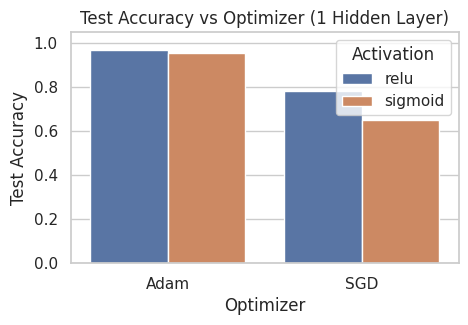

In [ ]:
# 2. Test Accuracy vs Optimizer for 1 hidden layer
plt.figure(figsize=(5,3))
df_1hidden = df_results[df_results['Hidden Layers']==1]
sns.barplot(data=df_1hidden, x='Optimizer', y='Test Acc', hue='Activation', errorbar=None)
plt.title('Test Accuracy vs Optimizer (1 Hidden Layer)')
plt.ylabel('Test Accuracy')
plt.xlabel('Optimizer')
plt.ylim(0,1.05)
plt.show()



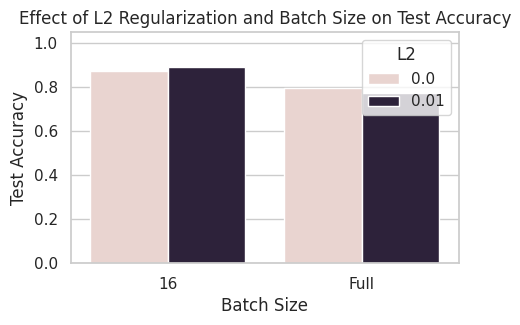

In [ ]:
# 3. Effect of L2 and Batch Size on Test Accuracy
plt.figure(figsize=(5,3))
sns.barplot(data=df_results, x='Batch Size', y='Test Acc', hue='L2', errorbar=None)
plt.title('Effect of L2 Regularization and Batch Size on Test Accuracy')
plt.ylabel('Test Accuracy')
plt.xlabel('Batch Size')
plt.ylim(0,1.05)
plt.show()

In [ ]:
import pandas as pd

# Create the results table (you can edit these values with your own)
data = {
    'Hidden Layers': [0,0,0,0,2,2,1,1,2,2],
    'Activation': ['relu','relu','sigmoid','sigmoid','relu','relu','relu','relu','relu','sigmoid'],
    'Optimizer': ['SGD','Adam','Adam','SGD','SGD','Adam','Adam','Adam','Adam','Adam'],
    'Batch Size': [16,16,16,16,16,16,16,16,16,16],
    'L2': [0.01,0,0,0.01,0.01,0.01,0.01,0,0,0],
    'Val Acc': [0.9091,0.9091,0.9091,0.9091,0.9091,0.9091,0.9091,0.9091,0.9091,0.9091],
    'Test Acc': [0.8261,0.9565,0.9565,0.8261,0.913,0.913,1.0,0.9565,0.913,0.9565]
}

df_results = pd.DataFrame(data)
print(df_results)


   Hidden Layers Activation Optimizer  Batch Size    L2  Val Acc  Test Acc
0              0       relu       SGD          16  0.01   0.9091    0.8261
1              0       relu      Adam          16  0.00   0.9091    0.9565
2              0    sigmoid      Adam          16  0.00   0.9091    0.9565
3              0    sigmoid       SGD          16  0.01   0.9091    0.8261
4              2       relu       SGD          16  0.01   0.9091    0.9130
5              2       relu      Adam          16  0.01   0.9091    0.9130
6              1       relu      Adam          16  0.01   0.9091    1.0000
7              1       relu      Adam          16  0.00   0.9091    0.9565
8              2       relu      Adam          16  0.00   0.9091    0.9130
9              2    sigmoid      Adam          16  0.00   0.9091    0.9565


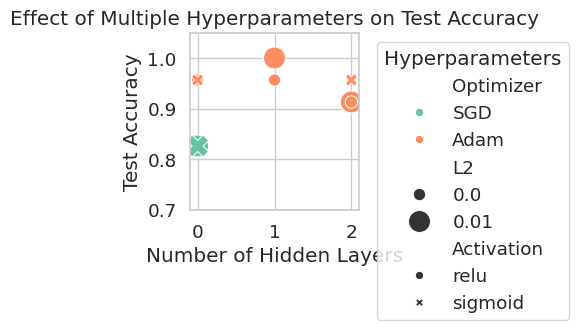

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(5,3))
sns.scatterplot(
    data=df_results,
    x='Hidden Layers',
    y='Test Acc',
    hue='Optimizer',
    style='Activation',
    size='L2',
    sizes=(80,250),
    palette='Set2'
)
plt.title('Effect of Multiple Hyperparameters on Test Accuracy')
plt.xlabel('Number of Hidden Layers')
plt.ylabel('Test Accuracy')
plt.ylim(0.7,1.05)
plt.legend(title='Hyperparameters', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()
